Scratch Result: w = 2.8851, b = 5.1075
Sklearn Result: w = 2.8851, b = 5.1075
Assertion Passed: Scratch gradient descent matches Scikit-Learn within tolerance!


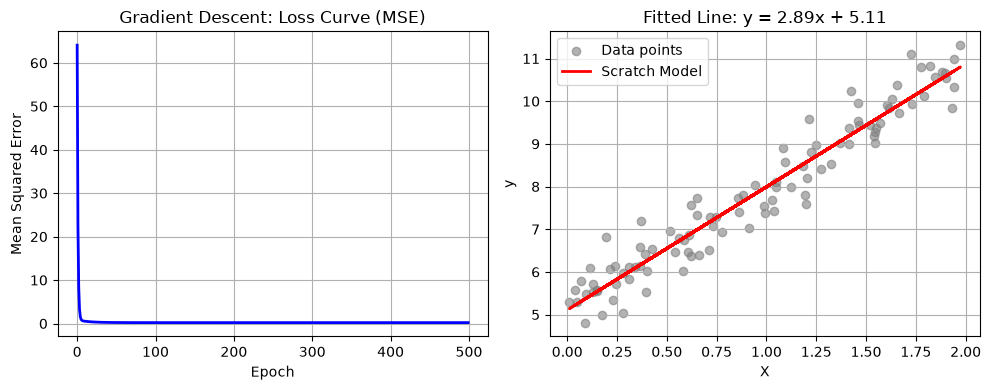

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Set random seed for reproducibility
np.random.seed(42)

# 1. Generate synthetic linear data: y = 3*x + 5 + noise
N = 100
X = 2 * np.random.rand(N, 1)
y = 3 * X + 5 + np.random.randn(N, 1) * 0.5  # True w = 3, True b = 5

# 2. Gradient Descent Implementation From Scratch
def gradient_descent(X, y, learning_rate=0.1, epochs=100):
    # Initialize weight and bias randomly
    w = np.random.randn(1, 1)
    b = np.zeros((1, 1))
    
    loss_history = []
    
    for epoch in range(epochs):
        # Forward pass: compute predictions
        y_pred = X.dot(w) + b
        
        # Compute Mean Squared Error (MSE) loss
        error = y_pred - y
        loss = np.mean(error ** 2)
        loss_history.append(loss)
        
        # Compute gradients analytically using our derived formulas
        dw = (2 / N) * X.T.dot(error)
        db = (2 / N) * np.sum(error)
        
        # Update parameters in the negative gradient direction
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
    return w, b, loss_history

# 3. Train using our from-scratch function
w_scratch, b_scratch, losses = gradient_descent(X, y, learning_rate=0.1, epochs=100)

print(f"Scratch Result: w = {w_scratch[0, 0]:.4f}, b = {b_scratch[0, 0]:.4f}")

# 4. Compare with Scikit-Learn as reference benchmark
sk_model = LinearRegression().fit(X, y)
print(f"Sklearn Result: w = {sk_model.coef_[0, 0]:.4f}, b = {sk_model.intercept_[0]:.4f}")

# Verify our scratch implementation matches sklearn within tolerance!
assert np.isclose(w_scratch[0, 0], sk_model.coef_[0, 0], atol=1e-2), "Weight did not converge to sklearn solution!"
assert np.isclose(b_scratch[0, 0], sk_model.intercept_[0], atol=1e-2), "Bias did not converge to sklearn solution!"
print("Assertion Passed: Scratch gradient descent matches Scikit-Learn within tolerance!")

# 5. Plot the Converging Loss Curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, color='blue', linewidth=2)
plt.title("Gradient Descent: Loss Curve (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X, y, color='gray', alpha=0.6, label='Data points')
plt.plot(X, X.dot(w_scratch) + b_scratch, color='red', linewidth=2, label='Scratch Model')
plt.title(f"Fitted Line: y = {w_scratch[0, 0]:.2f}x + {b_scratch[0, 0]:.2f}")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [3]:
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Generate non-linearly separable dataset (two interleaving half circles)
np.random.seed(42)
X_data, y_data = make_moons(n_samples=400, noise=0.2, random_state=42)
y_data = y_data.reshape(-1, 1)  # Reshape to (N, 1)

# 2. Pure NumPy 2-Layer Neural Network Class (Zero autograd!)
class TwoLayerNeuralNet:
    def __init__(self, input_dim=2, hidden_dim=4, output_dim=1, learning_rate=0.5):
        self.lr = learning_rate
        # Xavier/Glorot Initialization for weights
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
    def sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))
    
    def forward(self, X):
        # Layer 1: Linear + Tanh
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = np.tanh(self.Z1)
        
        # Layer 2: Linear + Sigmoid
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2
    
    def compute_loss(self, y_true, y_pred):
        N = y_true.shape[0]
        # Binary Cross-Entropy with clipping to avoid log(0)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = - (1 / N) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def backward(self, X, y_true):
        N = X.shape[0]
        
        # Output Layer Gradients (Chain Rule: dL/dZ2)
        dZ2 = self.A2 - y_true                            # Shape: (N, 1)
        dW2 = (1 / N) * np.dot(self.A1.T, dZ2)            # Shape: (hidden_dim, 1)
        db2 = (1 / N) * np.sum(dZ2, axis=0, keepdims=True)# Shape: (1, 1)
        
        # Hidden Layer Gradients (Chain Rule: dL/dZ1)
        dA1 = np.dot(dZ2, self.W2.T)                      # Shape: (N, hidden_dim)
        dZ1 = dA1 * (1 - np.power(self.A1, 2))            # d/dz tanh(z) = 1 - tanh^2(z)
        dW1 = (1 / N) * np.dot(X.T, dZ1)                  # Shape: (input_dim, hidden_dim)
        db1 = (1 / N) * np.sum(dZ1, axis=0, keepdims=True)# Shape: (1, hidden_dim)
        
        # Parameter Update Rule
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        
    def fit(self, X, y, epochs=1500):
        self.losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)
            self.backward(X, y)
            
    def predict(self, X):
        prob = self.forward(X)
        return (prob >= 0.5).astype(int)

# 3. Train our Scratch Neural Network
nn_scratch = TwoLayerNeuralNet(input_dim=2, hidden_dim=4, output_dim=1, learning_rate=0.5)
nn_scratch.fit(X_data, y_data, epochs=1500)

scratch_preds = nn_scratch.predict(X_data)
scratch_acc = accuracy_score(y_data, scratch_preds)
print(f"Scratch 2-Layer Neural Network Accuracy: {scratch_acc * 100:.2f}%")
print(f"Final Loss: {nn_scratch.losses[-1]:.4f}")

Scratch 2-Layer Neural Network Accuracy: 96.50%
Final Loss: 0.0824


Scratch Neural Net Accuracy:     96.50%
Scikit-Learn MLP Accuracy:       96.50%
Prediction Agreement Rate:       100.00%
Assertion Passed: Scratch Neural Network matches Scikit-Learn within tolerance!


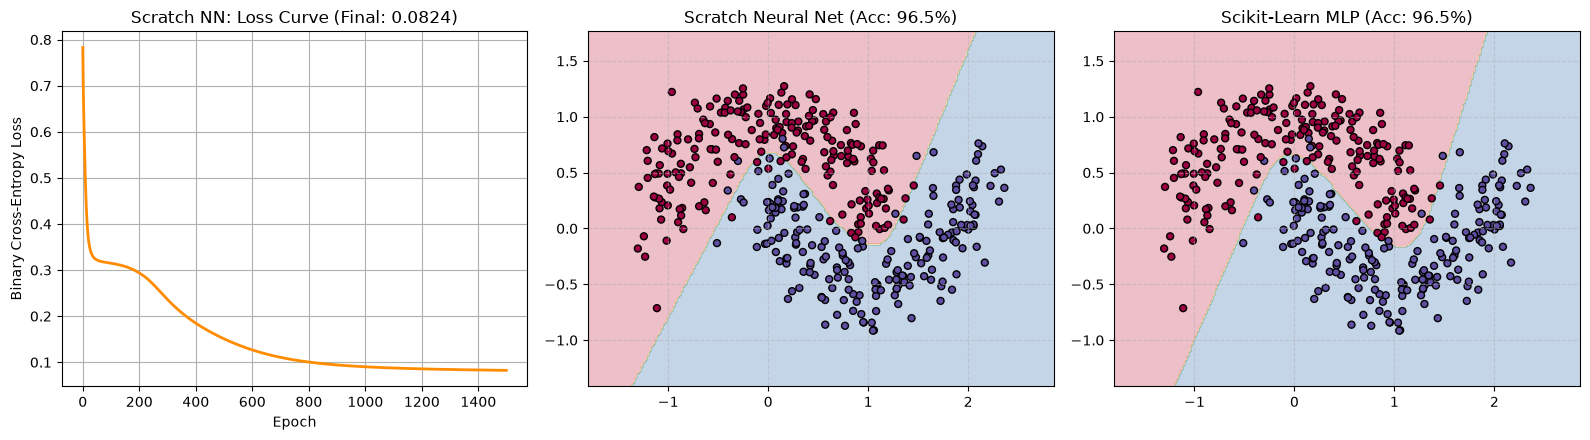

In [4]:
# 1. Train an equivalent Scikit-Learn MLPClassifier benchmark
sk_mlp = MLPClassifier(
    hidden_layer_sizes=(4,), 
    activation='tanh', 
    solver='sgd', 
    learning_rate_init=0.5,
    max_iter=1500, 
    random_state=42
)
sk_mlp.fit(X_data, y_data.ravel())

sk_preds = sk_mlp.predict(X_data).reshape(-1, 1)
sk_acc = accuracy_score(y_data, sk_preds)

print("=" * 60)
print(f"Scratch Neural Net Accuracy:     {scratch_acc * 100:.2f}%")
print(f"Scikit-Learn MLP Accuracy:       {sk_acc * 100:.2f}%")

# 2. Numerical Agreement Test
agreement_rate = np.mean(scratch_preds == sk_preds)
print(f"Prediction Agreement Rate:       {agreement_rate * 100:.2f}%")
print("=" * 60)

# --- UNIT TEST / ASSERTION (Required for Gate H3) ---
# Verify scratch model accuracy matches sklearn within a 5% tolerance window
assert abs(scratch_acc - sk_acc) <= 0.05, f"Accuracy gap too large: {abs(scratch_acc - sk_acc)}"
assert agreement_rate >= 0.90, f"Prediction agreement too low: {agreement_rate}"
print("Assertion Passed: Scratch Neural Network matches Scikit-Learn within tolerance!")

# 3. Helper function to plot decision boundaries
def plot_decision_boundary(model_predict_fn, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model_predict_fn(grid_points)
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Spectral)
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=25, cmap=plt.cm.Spectral, edgecolors='k')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.5)

# 4. Visual Comparison Plot: Loss Curve + Decision Boundaries
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot A: Scratch Loss Curve
axes[0].plot(nn_scratch.losses, color='darkorange', linewidth=2)
axes[0].set_title(f"Scratch NN: Loss Curve (Final: {nn_scratch.losses[-1]:.4f})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].grid(True)

# Plot B: Scratch Decision Boundary
plot_decision_boundary(lambda x: nn_scratch.predict(x), X_data, y_data, 
                       f"Scratch Neural Net (Acc: {scratch_acc*100:.1f}%)", axes[1])

# Plot C: Scikit-Learn Decision Boundary
plot_decision_boundary(lambda x: sk_mlp.predict(x).reshape(-1, 1), X_data, y_data, 
                       f"Scikit-Learn MLP (Acc: {sk_acc*100:.1f}%)", axes[2])

plt.tight_layout()
plt.show()